# Lab 09 - Text Visualization (Solution)

Muc tieu: truc quan hoa du lieu van ban theo huong **dung encoding**, **dung ngu canh**, va **co insight**.

## 0) Setup

In [1]:
from pathlib import Path
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.manifold import TSNE

sns.set_theme(style="whitegrid")
np.random.seed(42)

## 1) Tao dataset text mau (reviews)

In [2]:
raw = [
    ("2024-01-01", "positive", "The dashboard is clean, fast and very helpful for daily analysis"),
    ("2024-01-03", "negative", "The app is slow and crashes when loading large files"),
    ("2024-01-05", "positive", "Great visual design and smooth interactions"),
    ("2024-01-07", "negative", "Confusing navigation and poor documentation"),
    ("2024-01-08", "positive", "Useful filters and clear charts for managers"),
    ("2024-01-09", "negative", "The export feature fails and support is unresponsive"),
    ("2024-01-11", "positive", "Excellent performance on mobile and desktop"),
    ("2024-01-12", "negative", "Too many bugs after the recent update"),
    ("2024-01-14", "positive", "Loved the onboarding tutorial and examples"),
    ("2024-01-16", "negative", "Search is inaccurate and results are noisy"),
    ("2024-01-18", "positive", "The reporting module saves us a lot of time"),
    ("2024-01-19", "negative", "Hard to learn and settings are hidden"),
]

df = pd.DataFrame(raw, columns=["date", "label", "text"])
df["date"] = pd.to_datetime(df["date"])
df.head()

,date,label,text
0,2024-01-01,positive,"The dashboard is clean, fast and very helpful ..."
1,2024-01-03,negative,The app is slow and crashes when loading large...
2,2024-01-05,positive,Great visual design and smooth interactions
3,2024-01-07,negative,Confusing navigation and poor documentation
4,2024-01-08,positive,Useful filters and clear charts for managers


## 2) Text cleaning + tokenization

In [3]:
stop_words = set(ENGLISH_STOP_WORDS)

def clean_text(s: str) -> str:
    s = s.lower()
    s = re.sub(r"[^a-z\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def tokenize(s: str):
    return [w for w in s.split() if w not in stop_words and len(w) > 2]

df["clean_text"] = df["text"].map(clean_text)
df["tokens"] = df["clean_text"].map(tokenize)
df[["text", "clean_text", "tokens"]].head()

,text,clean_text,tokens
0,"The dashboard is clean, fast and very helpful ...",the dashboard is clean fast and very helpful f...,"[dashboard, clean, fast, helpful, daily, analy..."
1,The app is slow and crashes when loading large...,the app is slow and crashes when loading large...,"[app, slow, crashes, loading, large, files]"
2,Great visual design and smooth interactions,great visual design and smooth interactions,"[great, visual, design, smooth, interactions]"
3,Confusing navigation and poor documentation,confusing navigation and poor documentation,"[confusing, navigation, poor, documentation]"
4,Useful filters and clear charts for managers,useful filters and clear charts for managers,"[useful, filters, clear, charts, managers]"


## 3) Top words (bar chart)

/var/folders/v6/3bggzf691gn6h26h5hxxgq400000gp/T/ipykernel_281/455161169.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_words, x="count", y="word", palette="Blues_r")


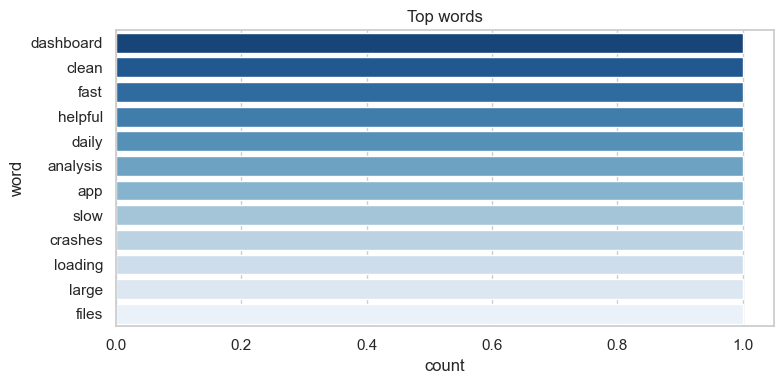

,word,count
0,dashboard,1
1,clean,1
2,fast,1
3,helpful,1
4,daily,1
5,analysis,1
6,app,1
7,slow,1
8,crashes,1
9,loading,1


In [4]:
all_tokens = [w for row in df["tokens"] for w in row]
word_counts = Counter(all_tokens)
top_words = pd.DataFrame(word_counts.most_common(12), columns=["word", "count"])

plt.figure(figsize=(8, 4))
sns.barplot(data=top_words, x="count", y="word", palette="Blues_r")
plt.title("Top words")
plt.tight_layout()
plt.show()
top_words

## 4) So sanh tu khoa theo label (lollipop/dot)

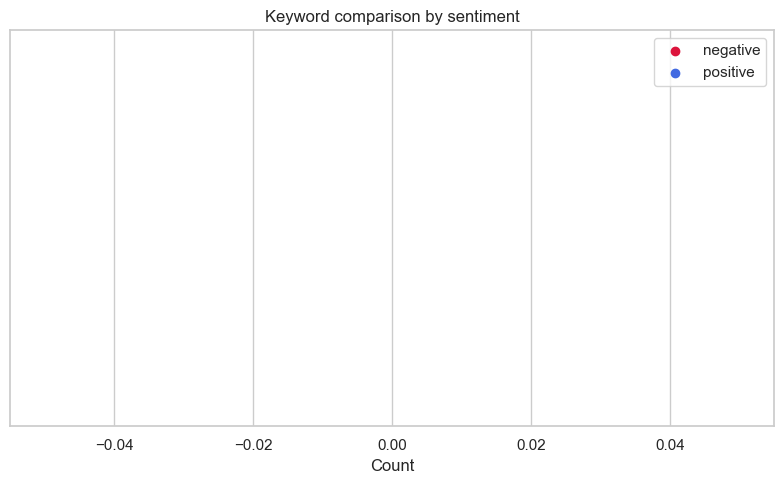

,word,positive,negative,gap


In [5]:
def label_word_freq(g):
    tokens = [w for row in g["tokens"] for w in row]
    return Counter(tokens)

pos = label_word_freq(df[df["label"] == "positive"])
neg = label_word_freq(df[df["label"] == "negative"])
vocab = sorted(set(pos) | set(neg))
cmp = pd.DataFrame({
    "word": vocab,
    "positive": [pos.get(w, 0) for w in vocab],
    "negative": [neg.get(w, 0) for w in vocab],
})
cmp["gap"] = cmp["positive"] - cmp["negative"]
cmp2 = cmp.loc[cmp[["positive", "negative"]].sum(axis=1) >= 2].copy()
cmp2 = cmp2.sort_values("gap").tail(10)

plt.figure(figsize=(8, 5))
for i, r in cmp2.reset_index(drop=True).iterrows():
    plt.plot([r["negative"], r["positive"]], [i, i], color="gray", alpha=0.5)
plt.scatter(cmp2["negative"], range(len(cmp2)), label="negative", color="crimson")
plt.scatter(cmp2["positive"], range(len(cmp2)), label="positive", color="royalblue")
plt.yticks(range(len(cmp2)), cmp2["word"])
plt.xlabel("Count")
plt.title("Keyword comparison by sentiment")
plt.legend()
plt.tight_layout()
plt.show()
cmp2

## 5) Bigram heatmap theo nhom

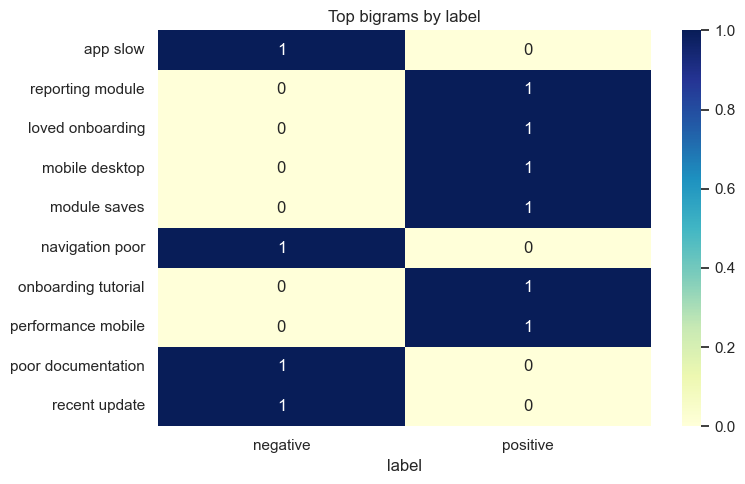

label,negative,positive
app slow,1,0
reporting module,0,1
loved onboarding,0,1
mobile desktop,0,1
module saves,0,1
navigation poor,1,0
onboarding tutorial,0,1
performance mobile,0,1
poor documentation,1,0
recent update,1,0


In [6]:
vec = CountVectorizer(ngram_range=(2, 2), stop_words="english")
X = vec.fit_transform(df["clean_text"])
bigrams = vec.get_feature_names_out()

tmp = pd.DataFrame(X.toarray(), columns=bigrams)
tmp["label"] = df["label"].values
agg = tmp.groupby("label").sum().T
agg["total"] = agg.sum(axis=1)
top_bi = agg.sort_values("total", ascending=False).head(10).drop(columns=["total"])

plt.figure(figsize=(8, 5))
sns.heatmap(top_bi, cmap="YlGnBu", annot=True, fmt=".0f")
plt.title("Top bigrams by label")
plt.tight_layout()
plt.show()
top_bi

## 6) TF-IDF: tu dac trung theo nhom

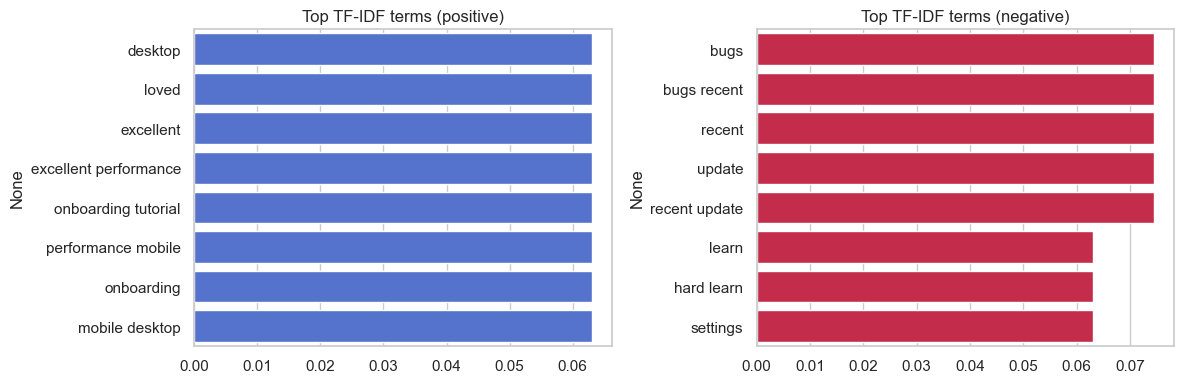

,positive,negative
bugs,NaN,0.074536
bugs recent,NaN,0.074536
desktop,0.062994,NaN
excellent,0.062994,NaN
excellent performance,0.062994,NaN
hard learn,NaN,0.062994
learn,NaN,0.062994
loved,0.062994,NaN
mobile desktop,0.062994,NaN
onboarding,0.062994,NaN


In [7]:
tfidf = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=1)
T = tfidf.fit_transform(df["clean_text"])
terms = np.array(tfidf.get_feature_names_out())

tfidf_df = pd.DataFrame(T.toarray(), columns=terms)
tfidf_df["label"] = df["label"].values
label_mean = tfidf_df.groupby("label").mean(numeric_only=True).T

top_pos = label_mean["positive"].sort_values(ascending=False).head(8)
top_neg = label_mean["negative"].sort_values(ascending=False).head(8)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=False)
sns.barplot(x=top_pos.values, y=top_pos.index, ax=axes[0], color="royalblue")
axes[0].set_title("Top TF-IDF terms (positive)")
sns.barplot(x=top_neg.values, y=top_neg.index, ax=axes[1], color="crimson")
axes[1].set_title("Top TF-IDF terms (negative)")
plt.tight_layout()
plt.show()
pd.DataFrame({"positive": top_pos, "negative": top_neg})

## 7) Sentiment score distribution + timeline

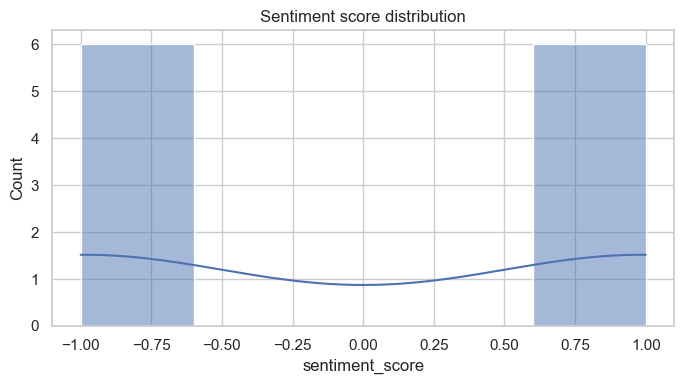

/Users/trungtv/miniforge3/lib/python3.10/site-packages/kaleido/__init__.py:14: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




,date,sentiment_score
0,2024-01-01,1.0
1,2024-01-03,-1.0
2,2024-01-05,1.0
3,2024-01-07,-1.0
4,2024-01-08,1.0
5,2024-01-09,-1.0
6,2024-01-11,1.0
7,2024-01-12,-1.0
8,2024-01-14,1.0
9,2024-01-16,-1.0


In [8]:
score_map = {"positive": 1.0, "negative": -1.0}
df["sentiment_score"] = df["label"].map(score_map)

plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="sentiment_score", bins=5, kde=True)
plt.title("Sentiment score distribution")
plt.tight_layout()
plt.show()

ts = df.sort_values("date").groupby("date", as_index=False)["sentiment_score"].mean()
fig = px.line(ts, x="date", y="sentiment_score", markers=True, title="Daily sentiment trend")
fig.add_hline(y=0, line_dash="dash", line_color="gray")
fig.show()
ts

## 8) Topic-level visualization (NMF)

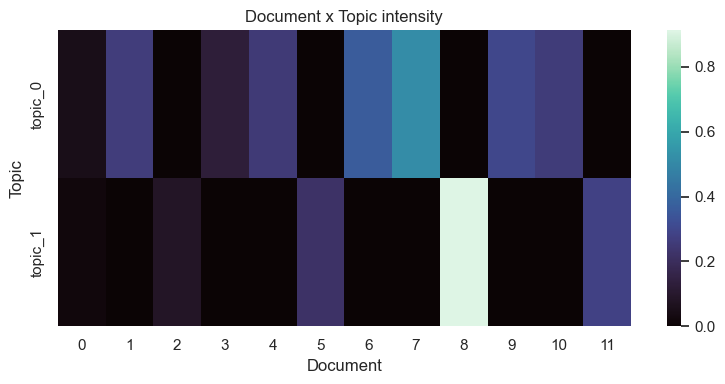

{'topic_0': 'update, bugs, recent, performance, excellent, mobile',
 'topic_1': 'examples, tutorial, onboarding, loved, settings, hidden'}

In [9]:
topic_vec = TfidfVectorizer(stop_words="english", min_df=1)
X_topic = topic_vec.fit_transform(df["clean_text"])
topic_terms = np.array(topic_vec.get_feature_names_out())

n_topics = 2
nmf = NMF(n_components=n_topics, random_state=42, init="nndsvda", max_iter=500)
W = nmf.fit_transform(X_topic)
H = nmf.components_

topic_names = [f"topic_{i}" for i in range(n_topics)]
doc_topics = pd.DataFrame(W, columns=topic_names)
doc_topics["doc_id"] = np.arange(len(doc_topics))

plt.figure(figsize=(8, 4))
sns.heatmap(doc_topics[topic_names].T, cmap="mako", cbar=True)
plt.title("Document x Topic intensity")
plt.xlabel("Document")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

top_terms = {}
for i in range(n_topics):
    idx = H[i].argsort()[::-1][:6]
    top_terms[f"topic_{i}"] = ", ".join(topic_terms[idx])
top_terms

## 9) Word embedding + t-SNE (term-level map)
Y tuong: dung vector term (tu ma tran term-document) nhu embedding phan bo, sau do giam chieu bang t-SNE de quan sat cum tu.

In [10]:
# Tao term vectors tu ma tran term-document
term_vec = CountVectorizer(stop_words="english", min_df=1, max_features=80)
X_term_doc = term_vec.fit_transform(df["clean_text"]).toarray()  # docs x terms
terms_td = np.array(term_vec.get_feature_names_out())

# Chon top terms theo tan suat de visualization on dinh hon
term_freq = X_term_doc.sum(axis=0)
top_idx = np.argsort(term_freq)[::-1][:25]
terms_top = terms_td[top_idx]
term_vectors = X_term_doc[:, top_idx].T  # terms x docs

# t-SNE cho term vectors
emb_2d = TSNE(
    n_components=2,
    perplexity=5,
    learning_rate="auto",
    init="pca",
    random_state=42,
).fit_transform(term_vectors)

# Tinh polarity score cua moi term: positive_count - negative_count
doc_sign = np.where(df["label"].eq("positive"), 1, -1)
polarity = (X_term_doc[:, top_idx] * doc_sign[:, None]).sum(axis=0)

term_map = pd.DataFrame(
    {
        "term": terms_top,
        "x": emb_2d[:, 0],
        "y": emb_2d[:, 1],
        "freq": term_freq[top_idx],
        "polarity": polarity,
    }
)

fig = px.scatter(
    term_map,
    x="x",
    y="y",
    size="freq",
    color="polarity",
    color_continuous_scale="RdBu",
    hover_name="term",
    title="t-SNE term embedding map",
)
fig.update_traces(textposition="top center")
fig.show()

term_map.sort_values("freq", ascending=False).head(10)

/Users/trungtv/miniforge3/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:996: FutureWarning:

The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.



,term,x,y,freq,polarity
0,visual,296.581024,-391.011047,1,1
13,documentation,-598.180664,-248.754547,1,-1
23,charts,109.952148,486.449554,1,1
22,clean,-464.096130,280.731750,1,1
21,clear,109.952148,486.449554,1,1
20,confusing,-569.272034,-151.843674,1,-1
19,crashes,54.980598,103.565903,1,-1
18,daily,-464.096130,280.731750,1,1
17,dashboard,-464.096130,280.731750,1,1
16,design,255.451920,-248.631256,1,1


## 10) Interactive storytelling view (Plotly)

In [11]:
term_df = top_words.copy()
fig_terms = px.bar(term_df, x="count", y="word", orientation="h", title="Interactive: top terms")
fig_terms.show()

label_count = df.groupby("label", as_index=False).size()
fig_label = px.pie(label_count, values="size", names="label", title="Label proportion")
fig_label.show()

## 11) Discussion: dung/sai trong text visualization
- Khong dung word cloud lam ket luan chinh.
- Can mo ta quy trinh clean text de tranh bias.
- So sanh theo nhom nen dung cung bo stopwords va cung preprocessing.
- t-SNE phu thuoc tham so (perplexity, random_state), dung de kham pha cum, khong dung de ket luan nhan qua.

## Reflection
1) Khi nao nen uu tien TF-IDF thay vi tan suat thuan?
2) Flow ke chuyen text cua ban gom 3 chart nao va vi sao?
3) Mot nguon sai lech (bias) lon nhat trong pipeline text hien tai la gi?